# Forgetting Metrics — Conv-Recurrent Network on CIFAR-10

Structured experiment notebook for studying catastrophic forgetting.

**Pipeline:**
1. **Runner** — one function collects all raw data for a single (hyperparams, image pair, seed) triple
2. **Metrics** — pure functions from raw data → scalar/array
3. **Sweeps** — for-loops over `(threshold, lr)` grids
4. **Plots** — one function per plot type

**Metrics implemented:**
| # | Name | What it measures |
|---|------|-----------------|
| 1 | Soft margin | Classification confidence at the output layer |
| 2 | Coexistence score $S$ | How often & continuously both memories coexist |
| 3 | Hidden stability margin | Local-field alignment at the hidden layers |
| 4 | Clamp-free distance | How much the state shifts when the label is unclamped |
| 5 | Flip rate | Fraction of neurons that change sign per dynamics step |
| 6 | Attractor consistency | Agreement of final states across different dynamics initializations |


## 1. Imports & Global Config

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from sklearn.metrics.pairwise import cosine_similarity

import jax
import jax.numpy as jnp
import jax.tree_util as jtu
import equinox as eqx
import optax

from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer
from darnax.layer_maps.sparse import LayerMap
from darnax.states.sequential import SequentialState
from darnax.orchestrators.sequential import SequentialOrchestrator
from darnax.datasets.classification.cifar10 import Cifar10

# ── Global dynamics config ─────────────────────────────────────────────
N_WARMUP  = 1
N_CLAMPED = 5
N_FREE    = 5

# ── Default forgetting protocol ────────────────────────────────────────
N_LEARN_A = 20   # weight updates in phase A
N_LEARN_B = 20   # weight updates in phase B

# ── Default network hyperparams ────────────────────────────────────────
MOMENTUM  = 0.5
MASK_PROB = 0.2

# ── Attractor consistency: number of re-runs per weight checkpoint ──────
N_ATTRACTOR_RUNS = 5


## 2. Dataset

In [2]:
data = Cifar10(batch_size=32, linear_projection=None, label_mode="pm1", x_transform="identity")
key = jax.random.PRNGKey(0)
key, data_key = jax.random.split(key)
data.build(key=data_key)

x, y = next(iter(data))
if x.ndim == 2:
    x = x.reshape(x.shape[0], 32, 32, 3)
x = (x - x.mean()) / x.std()

print(f"x: {x.shape}  y: {y.shape}")

# ── Image pairs used for pair-averaging ────────────────────────────────
IMAGE_PAIRS = [(0, 1), (2, 3), (4, 5)]
print("\nImage pairs:")
for ia, ib in IMAGE_PAIRS:
    print(f"  ({ia},{ib})  class A={int(np.array(y[ia:ia+1]).argmax())}  "
          f"class B={int(np.array(y[ib:ib+1]).argmax())}")


x: (32, 32, 32, 3)  y: (32, 10)

Image pairs:
  (0,1)  class A=3  class B=2
  (2,3)  class A=5  class B=7
  (4,5)  class A=2  class B=8


## 3. Model Helpers

Thin wrappers around the `darnax` building blocks. Nothing experiment-specific lives here.

In [11]:
def build_model(
    seed: int,
    threshold: float = 1.7,
    mask_prob: float = MASK_PROB,
    momentum: float = MOMENTUM,
    in_channels: int = 3,
    spatial_size: int = 32,
    n_channels: int = 64,
    num_labels: int = 10,
    input_kernel_size: int = 7,
    recur_kernel_size: int = 7,
    weight_decay_conv: float = 0.0
) -> tuple[SequentialState, SequentialOrchestrator]:
    """Build the 3-layer conv-recurrent model."""
    keys = jax.random.split(jax.random.key(seed), 5)
    S = spatial_size

    layer_map = LayerMap.from_dict({
        1: {
            0: Conv2D(in_channels=in_channels, out_channels=n_channels,
                      kernel_size=input_kernel_size, threshold=threshold,
                      strength=1.0, key=keys[0], padding_mode="constant"),
            1: Conv2DRecurrentDiscrete(channels=n_channels, kernel_size=recur_kernel_size,
                                       groups=n_channels, j_d=0.9, threshold=threshold,
                                       padding_mode="constant", key=keys[1], lr=1.0, weight_decay=weight_decay_conv),
            2: GlobalUnpooling(strength=1.0, axis=(1, 2)),
        },
        2: {
            1: GlobalMajorityPooling(strength=1.0, axis=(1, 2)),
            2: RecurrentDiscrete(features=n_channels, j_d=0.9,
                                  threshold=threshold, key=keys[2]),
            3: FrozenRescaledFullyConnected(in_features=num_labels, out_features=n_channels,
                                             strength=1.0, threshold=0.0, key=keys[3]),
        },
        3: {
            2: FullyConnected(in_features=n_channels, out_features=num_labels,
                               strength=1.0, threshold=threshold, key=keys[4]),
            3: OutputLayer(),
        },
    })
    state = SequentialState([(S, S, in_channels), (S, S, n_channels), (n_channels,), (num_labels,)])
    orchestrator = SequentialOrchestrator(layers=layer_map, field_momentum=momentum, mask_prob=mask_prob)
    return state, orchestrator


def build_optimizer(orchestrator: SequentialOrchestrator, lr: float):
    """SGD with the same lr for all trainable matrices."""
    trainable = {(1, 0): "w_in", (1, 1): "j_conv", (2, 2): "j_fc", (3, 2): "w_out"}
    params, _ = eqx.partition(orchestrator, eqx.is_inexact_array)
    labels = jtu.tree_map(lambda _: "frozen", params, is_leaf=eqx.is_array)

    def _label(tree, tag):
        return jtu.tree_map(lambda _: tag, tree, is_leaf=eqx.is_array)

    for (i, j), tag in trainable.items():
        labels = eqx.tree_at(lambda m, _i=i, _j=j: m.lmap[_i][_j], labels,
                              replace=_label(params.lmap[i][j], tag))

    transforms = {"frozen": optax.sgd(0.0)}
    transforms.update({tag: optax.sgd(lr) for tag in trainable.values()})
    optimizer = optax.multi_transform(transforms, labels)
    opt_state = optimizer.init(eqx.filter(orchestrator, eqx.is_inexact_array))
    return optimizer, opt_state


def run_dynamics(orchestrator, state, rng,
                 n_warmup=N_WARMUP, n_clamped=N_CLAMPED, n_free=N_FREE):
    """Run one full warmup + clamped + free pass; return (final_state, history)."""
    history = []
    for _ in range(n_warmup):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="inference")
        history.append(state)
    for _ in range(n_clamped):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="all")
        history.append(state)
    for _ in range(n_free):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="inference")
        history.append(state)
    return state, history


def apply_update(orchestrator, state, rng, optimizer, opt_state):
    """One Hebbian weight update; returns (new_orchestrator, new_opt_state)."""
    grads = orchestrator.backward(state, rng=rng)
    g_filt = eqx.filter(grads, eqx.is_inexact_array)
    p_filt = eqx.filter(orchestrator, eqx.is_inexact_array)
    updates, new_opt_state = optimizer.update(g_filt, opt_state, params=p_filt)
    return eqx.apply_updates(orchestrator, updates), new_opt_state


## 4. Core Trial Runner

`run_forgetting_trial` is the **only** function that calls the model.  
It returns a `TrialData` dict with all raw data needed by every metric function below.

In [5]:
def _predict_logits(orchestrator, state, rng):
    """Run free prediction and return raw output logits (numpy, shape (batch, L))."""
    rng, pred_rng = jax.random.split(rng)
    pred_state, _ = orchestrator.predict(state, pred_rng)
    return np.array(pred_state.states[-1]), rng


def _local_field_fc(orchestrator, state):
    """Hidden stability margin at the FC hidden layer (layer 2).
    h = Pool(s1) + s2@J + W_back(s3)  →  returns mean(s2 * h).
    """
    s1, s2, s3 = state.states[1], state.states[2], state.states[3]
    h = (orchestrator.lmap[2][1](s1) +   # GlobalMajorityPooling
         orchestrator.lmap[2][2](s2) +   # s2 @ J
         orchestrator.lmap[2][3](s3))    # W_back
    return float(jnp.mean(s2 * h))


def _local_field_conv(orchestrator, state):
    """Hidden stability margin at the conv hidden layer (layer 1).
    h = Conv_in(s0) + ConvRec(s1) + Unpool(s2)  →  returns mean(s1 * h).
    """
    s0, s1, s2 = state.states[0], state.states[1], state.states[2]
    h = (orchestrator.lmap[1][0](s0) +   # Conv2D
         orchestrator.lmap[1][1](s1) +   # ConvRec
         orchestrator.lmap[1][2](s2))    # GlobalUnpooling
    return float(jnp.mean(s1 * h))


def _cosine_dist(v1, v2):
    v1f, v2f = np.array(v1).ravel(), np.array(v2).ravel()
    return float(1.0 - np.dot(v1f, v2f) / (np.linalg.norm(v1f) * np.linalg.norm(v2f) + 1e-8))


def _mean_flip_rate(history, layer_idx):
    """Mean fraction of units that flip sign between consecutive dynamics steps."""
    acts = [np.array(h.states[layer_idx]).ravel() for h in history]
    if len(acts) < 2:
        return 0.0
    return float(np.mean([np.mean(np.sign(acts[t]) != np.sign(acts[t + 1]))
                           for t in range(len(acts) - 1)]))


def _attractor_consistency(orch, template_state_fn, rng, n_runs, layer_idx):
    """Re-run dynamics n_runs times; return mean pairwise cosine similarity of finals."""
    finals = []
    for _ in range(n_runs):
        s0 = template_state_fn()
        rng, dyn_rng = jax.random.split(rng)
        sf, _ = run_dynamics(orch, s0, rng=dyn_rng)
        finals.append(np.array(sf.states[layer_idx]).ravel())
    if len(finals) < 2:
        return 1.0, rng
    mat = cosine_similarity(finals)
    n = len(finals)
    score = float(np.mean([mat[i, j] for i in range(n) for j in range(i + 1, n)]))
    return score, rng


# ─────────────────────────────────────────────────────────────────────
def run_forgetting_trial(
    x_a, y_a, x_b, y_b,
    threshold: float,
    lr: float,
    seed: int = 0,
    n_learn_a: int = N_LEARN_A,
    n_learn_b: int = N_LEARN_B,
    n_attractor_runs: int = N_ATTRACTOR_RUNS,
) -> dict:
    """Run one full A→B forgetting trial and collect ALL raw data.

    Returns a dict with:
      'phase_a', 'phase_b' — each a dict of per-step metric lists
      'config'              — hyperparams used
    """
    st, orch = build_model(seed=seed, threshold=threshold)
    optimizer, opt_state = build_optimizer(orch, lr=lr)
    rng = jax.random.PRNGKey(seed)

    def _init_phase():
        return {k: [] for k in [
            "soft_margin_a", "soft_margin_b",
            "hidden_margin_fc", "hidden_margin_conv",
            "clamp_free_dist_l1", "clamp_free_dist_l2",
            "flip_rate_l1", "flip_rate_l2",
            "attractor_consistency_l1", "attractor_consistency_l2",
        ]}

    def _soft_margin(logits, y_true):
        y_np = np.array(y_true)
        tc = int(np.argmax(y_np))
        lg = logits[0]
        return float(lg[tc] - np.concatenate([lg[:tc], lg[tc + 1:]]).max())

    def _eval_one(orch_frozen, x_in, y_in, rng):
        """Dynamics + all metrics for a single (image, weight) pair. Returns (metrics, sf, rng)."""
        s0 = st.init(x_in, y_in)
        rng, dyn_rng = jax.random.split(rng)
        sf, history = run_dynamics(orch_frozen, s0, rng=dyn_rng)

        logits, rng = _predict_logits(orch_frozen, sf, rng)
        sm = _soft_margin(logits, y_in)

        hm_fc   = _local_field_fc(orch_frozen, sf)
        hm_conv = _local_field_conv(orch_frozen, sf)

        i_clamp = N_WARMUP + N_CLAMPED - 1
        i_free  = len(history) - 1
        cf_l1 = _cosine_dist(history[i_clamp].states[1], history[i_free].states[1])
        cf_l2 = _cosine_dist(history[i_clamp].states[2], history[i_free].states[2])

        fr_l1 = _mean_flip_rate(history, 1)
        fr_l2 = _mean_flip_rate(history, 2)

        ac_l1, rng = _attractor_consistency(
            orch_frozen, lambda: st.init(x_in, y_in), rng, n_attractor_runs, 1)
        ac_l2, rng = _attractor_consistency(
            orch_frozen, lambda: st.init(x_in, y_in), rng, n_attractor_runs, 2)

        m = dict(
            soft_margin=sm,
            hidden_margin_fc=hm_fc, hidden_margin_conv=hm_conv,
            clamp_free_dist_l1=cf_l1, clamp_free_dist_l2=cf_l2,
            flip_rate_l1=fr_l1, flip_rate_l2=fr_l2,
            attractor_consistency_l1=ac_l1, attractor_consistency_l2=ac_l2,
        )
        return m, sf, rng

    # ── Phase A: train on A ───────────────────────────────────────────
    phase_a = _init_phase()
    for step in range(n_learn_a + 1):
        m, sf_a, rng = _eval_one(orch, x_a, y_a, rng)
        phase_a["soft_margin_a"].append(m["soft_margin"])
        phase_a["soft_margin_b"].append(None)
        for k in ["hidden_margin_fc", "hidden_margin_conv",
                   "clamp_free_dist_l1", "clamp_free_dist_l2",
                   "flip_rate_l1", "flip_rate_l2",
                   "attractor_consistency_l1", "attractor_consistency_l2"]:
            phase_a[k].append(m[k])

        if step < n_learn_a:
            rng, upd_rng = jax.random.split(rng)
            orch, opt_state = apply_update(orch, sf_a, upd_rng, optimizer, opt_state)

    # ── Phase B: train on B, evaluate A and B each step ──────────────
    phase_b = _init_phase()
    for step in range(n_learn_b + 1):
        m_a, _,   rng = _eval_one(orch, x_a, y_a, rng)
        m_b, sf_b, rng = _eval_one(orch, x_b, y_b, rng)

        phase_b["soft_margin_a"].append(m_a["soft_margin"])
        phase_b["soft_margin_b"].append(m_b["soft_margin"])
        for k in ["hidden_margin_fc", "hidden_margin_conv",
                   "clamp_free_dist_l1", "clamp_free_dist_l2",
                   "flip_rate_l1", "flip_rate_l2",
                   "attractor_consistency_l1", "attractor_consistency_l2"]:
            # store both A and B evaluations as tuples
            phase_b[k].append((m_a[k], m_b[k]))

        if step < n_learn_b:
            rng, upd_rng = jax.random.split(rng)
            orch, opt_state = apply_update(orch, sf_b, upd_rng, optimizer, opt_state)

    return {"phase_a": phase_a, "phase_b": phase_b,
            "config": dict(threshold=threshold, lr=lr, seed=seed,
                           n_learn_a=n_learn_a, n_learn_b=n_learn_b)}


## 5. Metric Functions

Each function takes a `trial` dict (output of `run_forgetting_trial`) and returns one or more scalar/array summaries.  
They are **pure**: no model calls, no side effects.

| Metric | Input key(s) used |
|--------|------------------|
| Soft margin trajectory | `phase_a.soft_margin_a`, `phase_b.soft_margin_a/b` |
| Coexistence score $S$ | `phase_a.soft_margin_a`, `phase_b.soft_margin_a/b` |
| Hidden stability margin | `phase_*.hidden_margin_fc/conv` |
| Clamp-free distance | `phase_*.clamp_free_dist_l1/l2` |
| Flip rate | `phase_*.flip_rate_l1/l2` |
| Attractor consistency | `phase_*.attractor_consistency_l1/l2` |

In [6]:
# ── 5a. Soft Margin ───────────────────────────────────────────────────

def metric_soft_margin(trial: dict) -> dict:
    """Return the soft-margin trajectories for both phases.

    Returns
    -------
    dict with:
      'phase_a'   : np.array (n_learn_a+1,)   — margin on A during phase A
      'phase_b_a' : np.array (n_learn_b+1,)   — margin on A during phase B
      'phase_b_b' : np.array (n_learn_b+1,)   — margin on B during phase B
    """
    pa = trial["phase_a"]
    pb = trial["phase_b"]
    return {
        "phase_a":   np.array(pa["soft_margin_a"], dtype=float),
        "phase_b_a": np.array(pb["soft_margin_a"], dtype=float),
        "phase_b_b": np.array(pb["soft_margin_b"], dtype=float),
    }


# ── 5b. Coexistence Score ─────────────────────────────────────────────

def metric_coexistence_score(trial: dict) -> dict:
    """Compute S = g1 * g2 * sqrt(C_frac * C_max).

    g1 = 1 if A is stably learned at end of phase A (final margin_A > 0)
    g2 = 1 if B is learned at least once in phase B (some margin_B > 0)
    C_frac = fraction of phase-B steps where both A and B margins > 0
    C_max  = longest continuous such block, normalised by phase-B length

    Returns
    -------
    dict with scalar keys: 'S', 'g1', 'g2', 'C_frac', 'C_max',
    and array key 'coexist_mask' (bool array over phase-B steps)
    """
    sm = metric_soft_margin(trial)
    ma = sm["phase_b_a"]
    mb = sm["phase_b_b"]

    g1 = 1.0 if float(sm["phase_a"][-1]) > 0 else 0.0
    g2 = 1.0 if any(v > 0 for v in mb) else 0.0

    coexist = (ma > 0) & (mb > 0)
    n_b = len(ma)
    C_frac = float(coexist.sum()) / n_b

    max_run = cur_run = 0
    for c in coexist:
        cur_run = cur_run + 1 if c else 0
        max_run = max(max_run, cur_run)
    C_max = max_run / n_b

    S = g1 * g2 * float(np.sqrt(C_frac * C_max)) if (g1 and g2) else 0.0
    return dict(S=S, g1=g1, g2=g2, C_frac=C_frac, C_max=C_max, coexist_mask=coexist)


# ── 5c. Hidden Stability Margin ───────────────────────────────────────

def metric_hidden_stability(trial: dict) -> dict:
    """Hidden-layer s·h margin trajectory for both phases.

    In phase B, values are stored as (A_eval, B_eval) tuples — we unpack them.

    Returns
    -------
    dict with arrays for 'fc' and 'conv' margins in each phase:
      'phase_a_fc', 'phase_a_conv',
      'phase_b_a_fc', 'phase_b_b_fc',
      'phase_b_a_conv', 'phase_b_b_conv'
    """
    pa = trial["phase_a"]
    pb = trial["phase_b"]

    def _unpack(lst):
        if lst and isinstance(lst[0], tuple):
            return np.array([v[0] for v in lst]), np.array([v[1] for v in lst])
        return np.array(lst, dtype=float), None

    pa_fc   = np.array(pa["hidden_margin_fc"],   dtype=float)
    pa_conv = np.array(pa["hidden_margin_conv"],  dtype=float)
    pb_fc_a, pb_fc_b     = _unpack(pb["hidden_margin_fc"])
    pb_conv_a, pb_conv_b = _unpack(pb["hidden_margin_conv"])

    return dict(
        phase_a_fc=pa_fc, phase_a_conv=pa_conv,
        phase_b_a_fc=pb_fc_a,   phase_b_b_fc=pb_fc_b,
        phase_b_a_conv=pb_conv_a, phase_b_b_conv=pb_conv_b,
    )


# ── 5d. Clamp-Free Distance ───────────────────────────────────────────

def metric_clamp_free_distance(trial: dict) -> dict:
    """Cosine distance between end-of-clamped and end-of-free states.

    A large value means the network's free state diverges strongly from
    the clamped state — the network is not self-consistent.

    Returns per-step arrays for layer 1 and layer 2, in both phases.
    Phase-B values are (A_eval, B_eval) tuples — we unpack both.
    """
    pa = trial["phase_a"]
    pb = trial["phase_b"]

    def _unpack(lst):
        if lst and isinstance(lst[0], tuple):
            return np.array([v[0] for v in lst]), np.array([v[1] for v in lst])
        return np.array(lst, dtype=float), None

    pa_l1 = np.array(pa["clamp_free_dist_l1"], dtype=float)
    pa_l2 = np.array(pa["clamp_free_dist_l2"], dtype=float)
    pb_l1_a, pb_l1_b = _unpack(pb["clamp_free_dist_l1"])
    pb_l2_a, pb_l2_b = _unpack(pb["clamp_free_dist_l2"])

    return dict(
        phase_a_l1=pa_l1, phase_a_l2=pa_l2,
        phase_b_a_l1=pb_l1_a, phase_b_b_l1=pb_l1_b,
        phase_b_a_l2=pb_l2_a, phase_b_b_l2=pb_l2_b,
    )


# ── 5e. Flip Rate ─────────────────────────────────────────────────────

def metric_flip_rate(trial: dict) -> dict:
    """Mean fraction of units flipping sign per dynamics step.

    High flip rate = the network is still oscillating / not converged.
    Phase-B values are (A_eval, B_eval) tuples — we unpack both.
    """
    pa = trial["phase_a"]
    pb = trial["phase_b"]

    def _unpack(lst):
        if lst and isinstance(lst[0], tuple):
            return np.array([v[0] for v in lst]), np.array([v[1] for v in lst])
        return np.array(lst, dtype=float), None

    pa_l1 = np.array(pa["flip_rate_l1"], dtype=float)
    pa_l2 = np.array(pa["flip_rate_l2"], dtype=float)
    pb_l1_a, pb_l1_b = _unpack(pb["flip_rate_l1"])
    pb_l2_a, pb_l2_b = _unpack(pb["flip_rate_l2"])

    return dict(
        phase_a_l1=pa_l1, phase_a_l2=pa_l2,
        phase_b_a_l1=pb_l1_a, phase_b_b_l1=pb_l1_b,
        phase_b_a_l2=pb_l2_a, phase_b_b_l2=pb_l2_b,
    )


# ── 5f. Attractor Consistency ─────────────────────────────────────────

def metric_attractor_consistency(trial: dict) -> dict:
    """Mean pairwise cosine similarity of final states across dynamics re-runs.

    1.0 = all runs converge to the exact same state (strong attractor).
    0.0 = runs diverge completely (no stable attractor).
    Phase-B values are (A_eval, B_eval) tuples — we unpack both.
    """
    pa = trial["phase_a"]
    pb = trial["phase_b"]

    def _unpack(lst):
        if lst and isinstance(lst[0], tuple):
            return np.array([v[0] for v in lst]), np.array([v[1] for v in lst])
        return np.array(lst, dtype=float), None

    pa_l1 = np.array(pa["attractor_consistency_l1"], dtype=float)
    pa_l2 = np.array(pa["attractor_consistency_l2"], dtype=float)
    pb_l1_a, pb_l1_b = _unpack(pb["attractor_consistency_l1"])
    pb_l2_a, pb_l2_b = _unpack(pb["attractor_consistency_l2"])

    return dict(
        phase_a_l1=pa_l1, phase_a_l2=pa_l2,
        phase_b_a_l1=pb_l1_a, phase_b_b_l1=pb_l1_b,
        phase_b_a_l2=pb_l2_a, phase_b_b_l2=pb_l2_b,
    )


# ── Convenience: compute all metrics at once ──────────────────────────

def compute_all_metrics(trial: dict) -> dict:
    return {
        "soft_margin":        metric_soft_margin(trial),
        "coexistence":        metric_coexistence_score(trial),
        "hidden_stability":   metric_hidden_stability(trial),
        "clamp_free":         metric_clamp_free_distance(trial),
        "flip_rate":          metric_flip_rate(trial),
        "attractor":          metric_attractor_consistency(trial),
    }


## 6. Sweep Infrastructure

`run_sweep` iterates over a `(threshold, lr)` grid and, for each cell, collects trials either over **seeds** (fixed image pair, varying init) or over **image pairs** (fixed seed, varying images).  
All metrics are computed per individual trial, then averaged.

`sweep_results[(thr, lr)]` — a dict of metric summaries (mean ± std over trials).

In [7]:
def _average_metrics(metrics_list: list[dict]) -> dict:
    """Average a list of metric dicts (each from compute_all_metrics).

    For each leaf value:
      - scalars  → mean and std stored under 'mean' / 'std'
      - arrays   → element-wise mean and std

    Returns a nested dict mirroring the input structure.
    """
    keys_top = metrics_list[0].keys()
    out = {}
    for tk in keys_top:
        sub_keys = metrics_list[0][tk].keys()
        out[tk] = {}
        for sk in sub_keys:
            vals = [m[tk][sk] for m in metrics_list]
            # filter out None entries (soft_margin_b in phase A)
            vals = [v for v in vals if v is not None]
            if not vals:
                out[tk][sk] = {"mean": None, "std": None}
                continue
            arr = np.array(vals, dtype=float)
            out[tk][sk] = {"mean": arr.mean(axis=0), "std": arr.std(axis=0)}
    return out


def run_sweep(
    thresholds: list,
    lrs: list,
    x_data, y_data,
    mode: str = "seeds",           # "seeds" or "pairs"
    image_pair: tuple = (0, 1),    # used when mode="seeds"
    image_pairs: list = IMAGE_PAIRS,  # used when mode="pairs"
    n_seeds: int = 3,              # used when mode="seeds"
    fixed_seed: int = 0,           # used when mode="pairs"
    n_learn_a: int = N_LEARN_A,
    n_learn_b: int = N_LEARN_B,
    n_attractor_runs: int = N_ATTRACTOR_RUNS,
    verbose: bool = True,
) -> dict:
    """Run a (threshold × lr) sweep and return per-cell averaged metrics.

    Parameters
    ----------
    mode : "seeds"  → fixes image_pair, varies seed 0…n_seeds-1
           "pairs"  → fixes fixed_seed, varies over image_pairs

    Returns
    -------
    sweep_results : dict  keys (thr, lr) → averaged metrics dict
    """
    sweep_results = {}

    for thr in thresholds:
        for lr_val in lrs:
            if mode == "seeds":
                ia, ib = image_pair
                trials_raw = [
                    run_forgetting_trial(
                        x_data[ia:ia+1], y_data[ia:ia+1],
                        x_data[ib:ib+1], y_data[ib:ib+1],
                        threshold=thr, lr=lr_val, seed=s,
                        n_learn_a=n_learn_a, n_learn_b=n_learn_b,
                        n_attractor_runs=n_attractor_runs,
                    )
                    for s in range(n_seeds)
                ]
            else:  # "pairs"
                trials_raw = [
                    run_forgetting_trial(
                        x_data[ia:ia+1], y_data[ia:ia+1],
                        x_data[ib:ib+1], y_data[ib:ib+1],
                        threshold=thr, lr=lr_val, seed=fixed_seed,
                        n_learn_a=n_learn_a, n_learn_b=n_learn_b,
                        n_attractor_runs=n_attractor_runs,
                    )
                    for ia, ib in image_pairs
                ]

            metrics_list = [compute_all_metrics(t) for t in trials_raw]
            sweep_results[(thr, lr_val)] = _average_metrics(metrics_list)

        if verbose:
            print(f"  thr={thr:.3f} done")

    return sweep_results


## 7. Plotting Functions

Three plot families:
- **Trajectory plots** — per-step metric evolution for a single trial
- **Forgetting panel** — canonical A→B plot with phase A + phase B concatenated
- **Heatmaps** — scalar metric summary over the (threshold, lr) grid

In [8]:
# ── 7a. Helper for a single averaged trajectory ───────────────────────

def _plot_trajectory(ax, mean, std, steps, color, label, linestyle="-", marker="o"):
    mean = np.array(mean, dtype=float)
    std  = np.array(std,  dtype=float)
    ax.plot(steps, mean, color=color, lw=1.5, marker=marker, ms=2.5,
            linestyle=linestyle, label=label)
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.18)


# ── 7b. Forgetting panel (soft margin, A→B concatenated) ─────────────

def plot_forgetting_panel(avg_metrics: dict, config: dict, ax=None):
    """Single-axis A→B forgetting plot using averaged trial metrics.

    avg_metrics : output of _average_metrics (or compute_all_metrics for one trial)
    config      : trial config dict (threshold, lr, ...)
    ax          : if provided, draw into it (no plt.show)
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 3.5))

    sm = avg_metrics["soft_margin"]
    n_a = len(sm["phase_a"]["mean"])
    n_b = len(sm["phase_b_a"]["mean"])
    steps_a = np.arange(n_a)
    steps_b = np.arange(n_a - 1, n_a - 1 + n_b)

    _plot_trajectory(ax, sm["phase_a"]["mean"],   sm["phase_a"]["std"],   steps_a, "steelblue", "margin A", "-",  "o")
    _plot_trajectory(ax, sm["phase_b_a"]["mean"], sm["phase_b_a"]["std"], steps_b, "steelblue", None,       "--", "o")
    _plot_trajectory(ax, sm["phase_b_b"]["mean"], sm["phase_b_b"]["std"], steps_b, "darkorange","margin B", "-",  "s")

    boundary = n_a - 1
    ax.axvline(boundary, color="black", lw=0.9, ls=":", alpha=0.7)
    ax.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.5)

    forgotten = next((s for s, v in zip(steps_b, sm["phase_b_a"]["mean"]) if v < 0), None)
    if forgotten is not None:
        ax.axvline(forgotten, color="red", lw=0.9, ls=":", label=f"A forgotten@{forgotten}")

    ylim = ax.get_ylim()
    ax.text(boundary / 2, ylim[1], "Phase A", ha="center", va="top",
            fontsize=6, color="dimgray", style="italic")
    ax.text(boundary + n_b / 2, ylim[1], "Phase B", ha="center", va="top",
            fontsize=6, color="dimgray", style="italic")

    thr, lr = config.get("threshold", "?"), config.get("lr", "?")
    ax.set_title(f"thr={thr:.2f}, lr={lr:.3f}", fontsize=7, fontweight="bold")
    ax.set_xlabel("Update step", fontsize=7)
    ax.set_ylabel("Soft margin", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.12)
    ax.legend(fontsize=6, loc="lower right")

    if standalone:
        plt.tight_layout()
        plt.show()


# ── 7c. Full metric trajectory dashboard for a single trial ───────────

def plot_trial_dashboard(trial: dict, suptitle: str = ""):
    """6-row dashboard showing all metrics for one trial."""
    all_m = compute_all_metrics(trial)
    sm  = all_m["soft_margin"]
    hs  = all_m["hidden_stability"]
    cf  = all_m["clamp_free"]
    fr  = all_m["flip_rate"]
    ac  = all_m["attractor"]
    cfg = trial["config"]

    n_a = len(sm["phase_a"])
    n_b = len(sm["phase_b_a"])
    sa  = np.arange(n_a)
    sb  = np.arange(n_a - 1, n_a - 1 + n_b)

    fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=False)
    axes = axes.ravel()

    boundary = n_a - 1

    def _phase_lines(ax):
        ax.axvline(boundary, color="black", lw=0.8, ls=":", alpha=0.6)
        ax.axhline(0, color="gray", lw=0.7, ls="--", alpha=0.4)
        ax.grid(True, alpha=0.12)
        ax.tick_params(labelsize=6)

    def _wrap(v):
        """Wrap scalar into mean/std dict for _plot_trajectory."""
        a = np.array(v, dtype=float)
        return {"mean": a, "std": np.zeros_like(a)}

    # 1. Soft margin
    ax = axes[0]
    ax.plot(sa, sm["phase_a"],   color="steelblue",  lw=1.4, marker="o", ms=2, label="A (phase A)")
    ax.plot(sb, sm["phase_b_a"], color="steelblue",  lw=1.4, marker="o", ms=2, ls="--", label="A (phase B)")
    ax.plot(sb, sm["phase_b_b"], color="darkorange", lw=1.4, marker="s", ms=2, label="B")
    ax.set_title("Soft Margin", fontsize=8, fontweight="bold")
    ax.legend(fontsize=6); _phase_lines(ax)

    # 2. Coexistence score components
    cx = all_m["coexistence"]
    ax = axes[1]
    coex = cx["coexist_mask"].astype(float)
    ax.step(sb, coex, color="seagreen", lw=1.4, where="mid", label="coexistence")
    ax.set_ylim(-0.1, 1.3)
    ax.set_title(f"Coexistence  S={cx['S']:.3f}  C_frac={cx['C_frac']:.2f}  C_max={cx['C_max']:.2f}",
                 fontsize=8, fontweight="bold")
    ax.legend(fontsize=6); _phase_lines(ax)

    # 3. Hidden stability margin (FC hidden layer)
    ax = axes[2]
    ax.plot(sa, hs["phase_a_fc"], color="purple", lw=1.4, marker="o", ms=2, label="A (phase A)")
    if hs["phase_b_a_fc"] is not None:
        ax.plot(sb, hs["phase_b_a_fc"], color="purple",  lw=1.4, ms=2, ls="--", label="A (phase B)")
        ax.plot(sb, hs["phase_b_b_fc"], color="orchid",  lw=1.4, ms=2, label="B (phase B)")
    ax.set_title("Hidden Stability Margin (FC layer)", fontsize=8, fontweight="bold")
    ax.legend(fontsize=6); _phase_lines(ax)

    # 4. Clamp-free distance (layer 1)
    ax = axes[3]
    ax.plot(sa, cf["phase_a_l1"], color="sienna", lw=1.4, marker="o", ms=2, label="A (phase A)")
    if cf["phase_b_a_l1"] is not None:
        ax.plot(sb, cf["phase_b_a_l1"], color="sienna", lw=1.4, ms=2, ls="--", label="A (phase B)")
        ax.plot(sb, cf["phase_b_b_l1"], color="peru",   lw=1.4, ms=2, label="B (phase B)")
    ax.set_title("Clamp-Free Distance (layer 1)", fontsize=8, fontweight="bold")
    ax.legend(fontsize=6); _phase_lines(ax)

    # 5. Flip rate (layer 1)
    ax = axes[4]
    ax.plot(sa, fr["phase_a_l1"], color="teal", lw=1.4, marker="o", ms=2, label="A (phase A)")
    if fr["phase_b_a_l1"] is not None:
        ax.plot(sb, fr["phase_b_a_l1"], color="teal",      lw=1.4, ms=2, ls="--", label="A (phase B)")
        ax.plot(sb, fr["phase_b_b_l1"], color="mediumaquamarine", lw=1.4, ms=2, label="B (phase B)")
    ax.set_title("Flip Rate (layer 1)", fontsize=8, fontweight="bold")
    ax.legend(fontsize=6); _phase_lines(ax)

    # 6. Attractor consistency (layer 1)
    ax = axes[5]
    ax.plot(sa, ac["phase_a_l1"], color="navy", lw=1.4, marker="o", ms=2, label="A (phase A)")
    if ac["phase_b_a_l1"] is not None:
        ax.plot(sb, ac["phase_b_a_l1"], color="navy",       lw=1.4, ms=2, ls="--", label="A (phase B)")
        ax.plot(sb, ac["phase_b_b_l1"], color="cornflowerblue", lw=1.4, ms=2, label="B (phase B)")
    ax.set_title("Attractor Consistency (layer 1)", fontsize=8, fontweight="bold")
    ax.legend(fontsize=6); _phase_lines(ax)

    title = suptitle or (f"thr={cfg['threshold']:.2f}, lr={cfg['lr']:.3f}  |  "
                         f"N_A={cfg['n_learn_a']}, N_B={cfg['n_learn_b']}")
    fig.suptitle(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()


In [9]:
# ── 7d. Sweep heatmaps ────────────────────────────────────────────────

_SCALAR_METRICS = {
    # (metric_top_key, sub_key_path, display_name, cmap, vmin, vmax)
    # sub_key_path is a tuple: (metric_name, scalar_key)
    "S (coexistence score)":       ("coexistence", "S",       "YlGn",   0, 1),
    "C_frac":                      ("coexistence", "C_frac",  "YlGn",   0, 1),
    "C_max":                       ("coexistence", "C_max",   "YlGn",   0, 1),
    "Soft margin A (end phase A)": ("soft_margin", "phase_a", "RdYlGn", None, None),
    "Attractor cons. l1 (phase A)":("attractor",   "phase_a_l1", "YlGn", 0, 1),
    "Flip rate l1 (phase A)":      ("flip_rate",   "phase_a_l1", "YlOrRd", 0, None),
    "Hidden margin FC (phase A)":  ("hidden_stability", "phase_a_fc", "RdYlGn", None, None),
    "Clamp-free dist l1 (phase A)":("clamp_free",  "phase_a_l1", "YlOrRd", 0, None),
}


def _extract_scalar(cell: dict, metric_key: str, sub_key: str) -> float:
    """Extract a scalar from an averaged-metrics cell."""
    val = cell[metric_key][sub_key]["mean"] if isinstance(cell[metric_key][sub_key], dict) \
          else cell[metric_key][sub_key]
    if isinstance(val, np.ndarray):
        val = float(val[-1])   # take the last step value for trajectories
    return float(val) if val is not None else np.nan


def plot_sweep_heatmaps(
    sweep_results: dict,
    thresholds: list,
    lrs: list,
    title: str = "",
    metrics_to_plot: dict = None,
):
    """Grid of heatmaps, one per scalar metric, over the (threshold × lr) sweep.

    Parameters
    ----------
    metrics_to_plot : dict  name → (metric_key, sub_key, cmap, vmin, vmax)
                     defaults to _SCALAR_METRICS
    """
    if metrics_to_plot is None:
        metrics_to_plot = _SCALAR_METRICS

    n_metrics = len(metrics_to_plot)
    n_cols = min(4, n_metrics)
    n_rows = int(np.ceil(n_metrics / n_cols))
    n_thr, n_lr = len(thresholds), len(lrs)
    lr_labels  = [f"{l:.3f}" for l in lrs]
    thr_labels = [f"{t:.2f}" for t in thresholds]
    ann_fs = max(5, 9 - n_thr // 3)

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(4.5 * n_cols, 3.8 * n_rows))
    axes = np.array(axes).ravel()

    for idx, (name, (mk, sk, cmap, vmin, vmax)) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        mat = np.full((n_thr, n_lr), np.nan)
        for r, thr in enumerate(thresholds):
            for c, lr_val in enumerate(lrs):
                cell = sweep_results[(thr, lr_val)]
                mat[r, c] = _extract_scalar(cell, mk, sk)

        v0 = float(np.nanmin(mat)) if vmin is None else vmin
        v1 = float(np.nanmax(mat)) if vmax is None else vmax
        if cmap == "RdYlGn" and vmin is None:
            absmax = max(abs(v0), abs(v1)) + 1e-6
            v0, v1 = -absmax, absmax

        masked = np.ma.masked_invalid(mat)
        cm = plt.get_cmap(cmap).copy()
        cm.set_bad("lightgray")
        im = ax.imshow(masked, cmap=cm, vmin=v0, vmax=v1, aspect="auto")
        ax.set_xticks(range(n_lr)); ax.set_xticklabels(lr_labels, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(n_thr)); ax.set_yticklabels(thr_labels, fontsize=7)
        ax.set_xlabel("LR", fontsize=7); ax.set_ylabel("Threshold", fontsize=7)
        ax.set_title(name, fontsize=8, fontweight="bold")
        for r in range(n_thr):
            for c in range(n_lr):
                v = mat[r, c]
                txt = "—" if np.isnan(v) else f"{v:.2f}"
                ax.text(c, r, txt, ha="center", va="center", fontsize=ann_fs,
                        color="white" if abs((v - v0) / (v1 - v0 + 1e-8)) > 0.7 else "black")
        plt.colorbar(im, ax=ax, shrink=0.8)

    # hide unused axes
    for ax in axes[n_metrics:]:
        ax.set_visible(False)

    fig.suptitle(title or "Sweep heatmaps", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_sweep_forgetting_grid(
    sweep_results: dict,
    thresholds: list,
    lrs: list,
    title: str = "",
):
    """5×5 grid of forgetting panels (soft margin A→B) over the sweep."""
    n_thr, n_lr = len(thresholds), len(lrs)
    fig, axes = plt.subplots(n_thr, n_lr,
                              figsize=(3.8 * n_lr, 2.6 * n_thr),
                              sharex=True, sharey=True)
    for r, thr in enumerate(thresholds):
        for c, lr_val in enumerate(lrs):
            ax = axes[r, c]
            cell = sweep_results[(thr, lr_val)]
            cfg  = dict(threshold=thr, lr=lr_val)
            plot_forgetting_panel(cell, cfg, ax=ax)
            if r == 0:
                ax.set_title(f"lr={lr_val:.3f}", fontsize=8, fontweight="bold")
            else:
                ax.set_title("")
            if c == 0:
                ax.set_ylabel(f"thr={thr:.2f}\n{ax.get_ylabel()}", fontsize=7)
            else:
                ax.set_ylabel("")
    fig.suptitle(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 8. Single Trial — Example Run

Run one trial with a fixed hyperparameter setting and visualise all metrics.

In [12]:
# ── Hyperparams for the example trial ─────────────────────────────────
EXAMPLE_THRESHOLD = 2.5
EXAMPLE_LR        = 0.2
EXAMPLE_SEED      = 0
EXAMPLE_PAIR      = (0, 1)   # (idx_a, idx_b)

ia, ib = EXAMPLE_PAIR
print(f"Running single trial: pair=({ia},{ib})  "
      f"class A={int(np.array(y[ia:ia+1]).argmax())}  "
      f"class B={int(np.array(y[ib:ib+1]).argmax())}")
print(f"threshold={EXAMPLE_THRESHOLD}  lr={EXAMPLE_LR}  seed={EXAMPLE_SEED}")

example_trial = run_forgetting_trial(
    x[ia:ia+1], y[ia:ia+1],
    x[ib:ib+1], y[ib:ib+1],
    threshold=EXAMPLE_THRESHOLD,
    lr=EXAMPLE_LR,
    seed=EXAMPLE_SEED,
)

# Print coexistence score summary
cx = metric_coexistence_score(example_trial)
print(f"\nCoexistence: S={cx['S']:.3f}  g1={cx['g1']}  g2={cx['g2']}  "
      f"C_frac={cx['C_frac']:.2f}  C_max={cx['C_max']:.2f}")


Running single trial: pair=(0,1)  class A=3  class B=2
threshold=2.5  lr=0.2  seed=0

Coexistence: S=0.190  g1=1.0  g2=1.0  C_frac=0.19  C_max=0.19


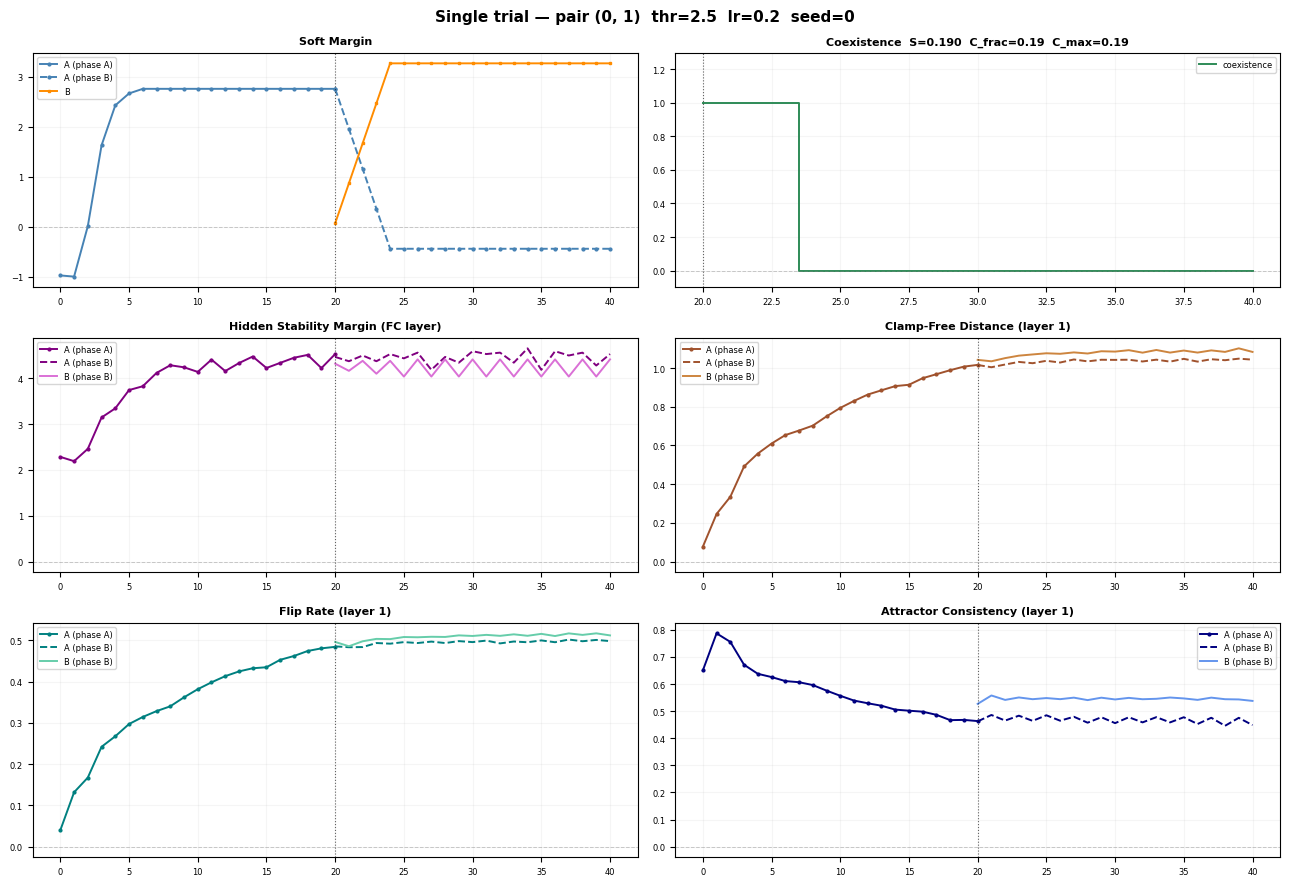

In [13]:
plot_trial_dashboard(
    example_trial,
    suptitle=(f"Single trial — pair {EXAMPLE_PAIR}  "
              f"thr={EXAMPLE_THRESHOLD}  lr={EXAMPLE_LR}  seed={EXAMPLE_SEED}")
)


## 9. Hyperparameter Sweep

Two sweeps over a 5×5 `(threshold × lr)` grid:
- **Seed sweep** — fixed pair `(0,1)`, average over 3 seeds → measures sensitivity to weight init
- **Pair sweep** — fixed seed 0, average over 3 image pairs → measures sensitivity to image content

In [14]:
# ── Sweep grid ────────────────────────────────────────────────────────
SWEEP_THRESHOLDS = [0.5, 1.0, 1.7, 2.5, 3.5]
SWEEP_LRS        = [0.02, 0.05, 0.1, 0.2, 0.5]
SWEEP_N_SEEDS    = 3
SWEEP_FIXED_PAIR = (0, 1)
SWEEP_FIXED_SEED = 0
SWEEP_IMAGE_PAIRS = IMAGE_PAIRS   # [(0,1), (2,3), (4,5)]

n_combos = len(SWEEP_THRESHOLDS) * len(SWEEP_LRS)
print(f"Grid: {len(SWEEP_THRESHOLDS)} × {len(SWEEP_LRS)} = {n_combos} combos")
print(f"Seed sweep: {SWEEP_N_SEEDS} seeds, pair {SWEEP_FIXED_PAIR}")
print(f"Pair sweep: {len(SWEEP_IMAGE_PAIRS)} pairs, seed={SWEEP_FIXED_SEED}")
print(f"Attractor runs per eval: {N_ATTRACTOR_RUNS}")
print(f"Total eval calls per combo (seed sweep): "
      f"{SWEEP_N_SEEDS} × (2×(N_A+N_B+2) + attractor overhead)")


Grid: 5 × 5 = 25 combos
Seed sweep: 3 seeds, pair (0, 1)
Pair sweep: 3 pairs, seed=0
Attractor runs per eval: 5
Total eval calls per combo (seed sweep): 3 × (2×(N_A+N_B+2) + attractor overhead)


In [15]:
print("Running SEED sweep ...")
sweep_seeds = run_sweep(
    SWEEP_THRESHOLDS, SWEEP_LRS, x, y,
    mode="seeds",
    image_pair=SWEEP_FIXED_PAIR,
    n_seeds=SWEEP_N_SEEDS,
)

Running SEED sweep ...
  thr=0.500 done
  thr=1.000 done
  thr=1.700 done


KeyboardInterrupt: 

In [ ]:
print("\nRunning PAIR sweep ...")
sweep_pairs = run_sweep(
    SWEEP_THRESHOLDS, SWEEP_LRS, x, y,
    mode="pairs",
    image_pairs=SWEEP_IMAGE_PAIRS,
    fixed_seed=SWEEP_FIXED_SEED,
)
print("\nBoth sweeps complete.")

## 10. Results — Forgetting Panels & Heatmaps

In [ ]:
# ── Forgetting grids ──────────────────────────────────────────────────
plot_sweep_forgetting_grid(
    sweep_seeds, SWEEP_THRESHOLDS, SWEEP_LRS,
    title=(f"Soft Margin — SEED avg  ({SWEEP_N_SEEDS} seeds, pair {SWEEP_FIXED_PAIR})  [shared y]"),
)

plot_sweep_forgetting_grid(
    sweep_pairs, SWEEP_THRESHOLDS, SWEEP_LRS,
    title=(f"Soft Margin — PAIR avg  ({len(SWEEP_IMAGE_PAIRS)} pairs, seed={SWEEP_FIXED_SEED})  [shared y]"),
)


In [ ]:
# ── Metric heatmaps — seed averaging ──────────────────────────────────
plot_sweep_heatmaps(
    sweep_seeds, SWEEP_THRESHOLDS, SWEEP_LRS,
    title=(f"All metrics — SEED avg  ({SWEEP_N_SEEDS} seeds, pair {SWEEP_FIXED_PAIR})\n"
           f"N_learn_A={N_LEARN_A}, N_learn_B={N_LEARN_B}, "
           f"momentum={MOMENTUM}, mask={MASK_PROB}"),
)


In [ ]:
# ── Metric heatmaps — pair averaging ──────────────────────────────────
plot_sweep_heatmaps(
    sweep_pairs, SWEEP_THRESHOLDS, SWEEP_LRS,
    title=(f"All metrics — PAIR avg  ({len(SWEEP_IMAGE_PAIRS)} pairs, seed={SWEEP_FIXED_SEED})\n"
           f"N_learn_A={N_LEARN_A}, N_learn_B={N_LEARN_B}, "
           f"momentum={MOMENTUM}, mask={MASK_PROB}"),
)
